In [1]:
import pandas as pd   # data analysis and manipulation tools
import seaborn as sns # data visualization library
import matplotlib.pyplot as plt

In [2]:
reviews = pd.read_csv("data/02-wine-reviews.csv", index_col=0)
reviews.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


# Univariate Analysis

### Distribution Visualization (Numerical Data)

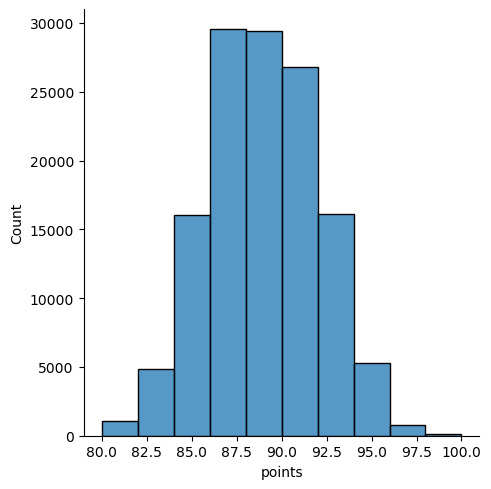

In [3]:
# Histogram 
sns.displot(data=reviews, x='points', bins=10, kde=False)

<Axes: xlabel='points', ylabel='Density'>

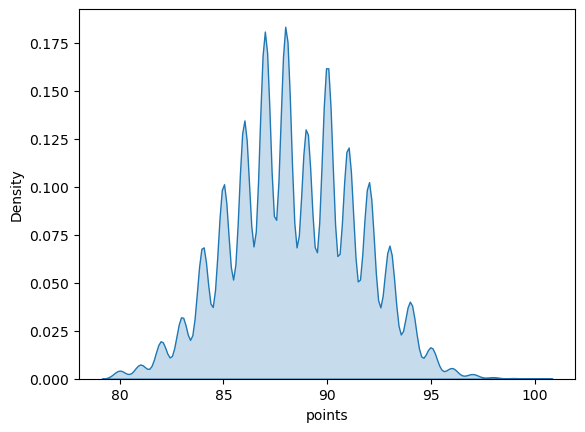

In [4]:
# Basic KDE Plot
sns.kdeplot(data=reviews, x='points', fill=True)

### Categorical Variables

<Axes: xlabel='country', ylabel='count'>

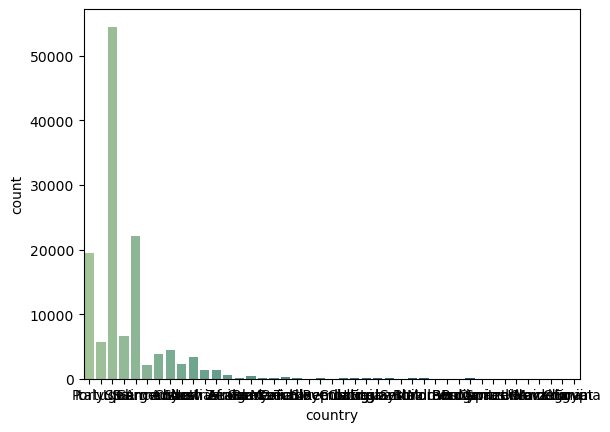

In [5]:
# Bar chart
sns.countplot(data=reviews, x='country', hue='country', palette="crest", legend=False)

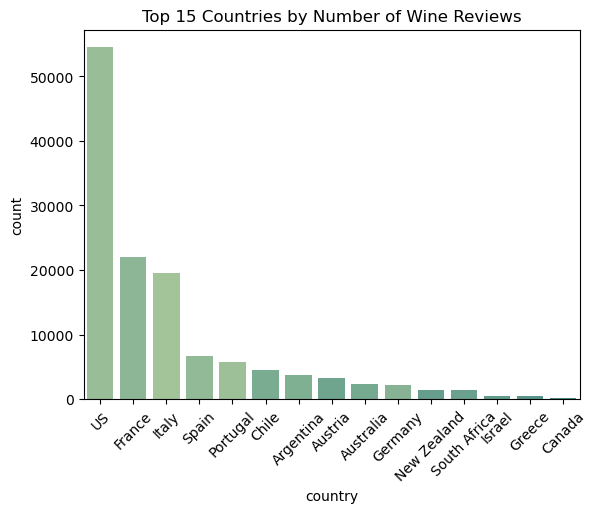

In [6]:
order = reviews['country'].value_counts().head(15).index

sns.countplot(data=reviews, x='country', order=order, hue='country', palette="crest", legend=False)

plt.xticks(rotation=45)
plt.title("Top 15 Countries by Number of Wine Reviews")
plt.show()

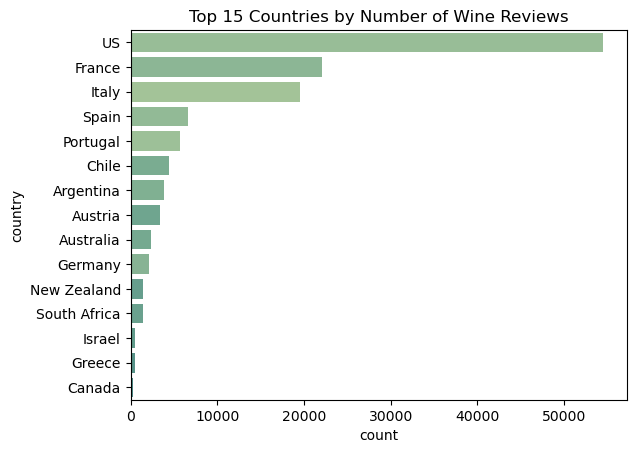

In [7]:
# Horizontal bar chart (for long labels)
sns.countplot(data=reviews, y='country', order=order, hue='country', palette="crest", legend=False)

plt.title("Top 15 Countries by Number of Wine Reviews")
plt.show()

# Bivariate Analysis (Relationships Between Variables)

In [8]:
# Keep only rows with valid price
df = reviews[['price', 'points']].dropna()

# Optional: remove extreme outliers for better visualization
df = df[df['price'] < 100]

### Numerical vs Numerical

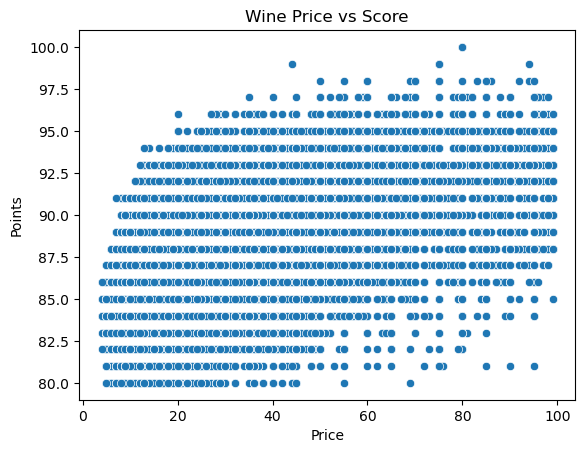

In [9]:
# Scatter plot
sns.scatterplot(data=df, x='price', y='points')

plt.title("Wine Price vs Score")
plt.xlabel("Price")
plt.ylabel("Points")
plt.show()

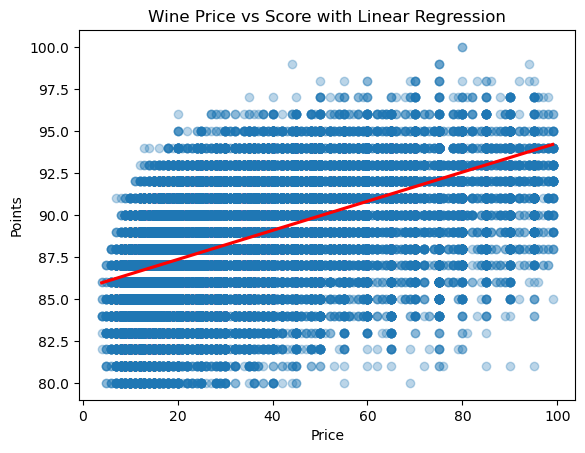

In [10]:
# Add regression line
sns.regplot(data=df, x='price', y='points', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})

plt.title("Wine Price vs Score with Linear Regression")
plt.xlabel("Price")
plt.ylabel("Points")
plt.show()

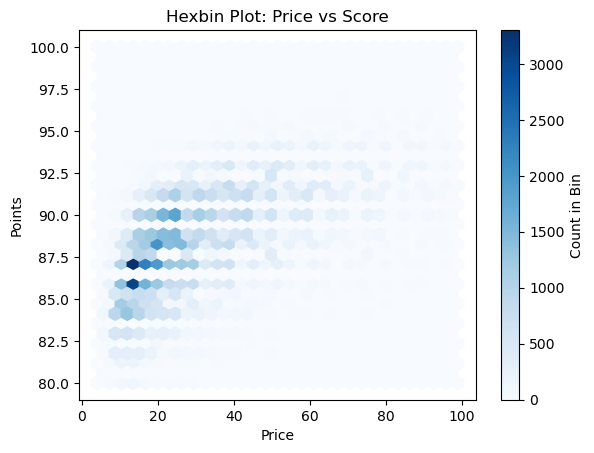

In [11]:
# Hexbin Plot (Matplotlib)
plt.hexbin(df['price'], df['points'], gridsize=30, cmap='Blues')

plt.colorbar(label='Count in Bin')
plt.xlabel("Price")
plt.ylabel("Points")
plt.title("Hexbin Plot: Price vs Score")
plt.show()

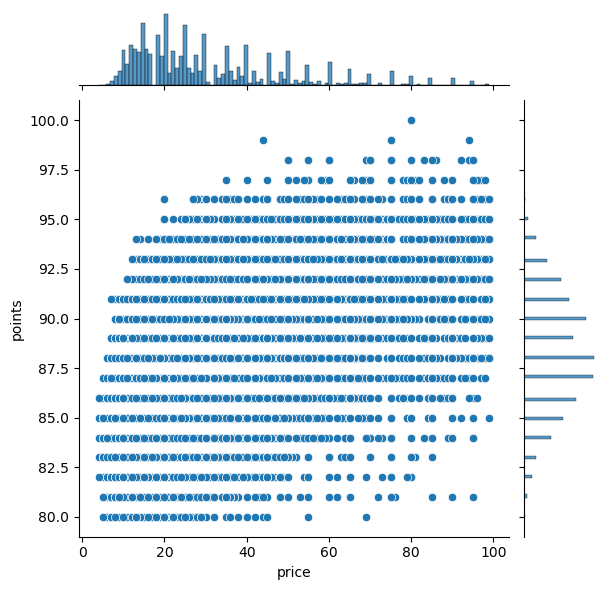

In [12]:
# Joint plot
sns.jointplot(data=df, x='price', y='points')

### Numerical vs Categorical

In [13]:
df = reviews[reviews.variety.isin(reviews.variety.value_counts().head(5).index)]

C:\Users\vira.liubchenko\AppData\Local\Temp\ipykernel_19416\1576866945.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='variety', y='points', palette='Set2')


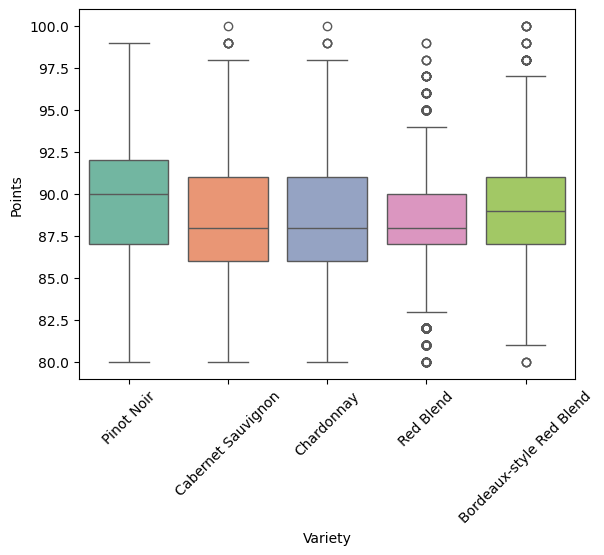

In [14]:
# Box plot
sns.boxplot(data=df, x='variety', y='points', palette='Set2')

plt.xlabel("Variety")
plt.xticks(rotation=45)
plt.ylabel("Points")
plt.show()

C:\Users\vira.liubchenko\AppData\Local\Temp\ipykernel_19416\1869072636.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='variety', y='points', palette='Set2')


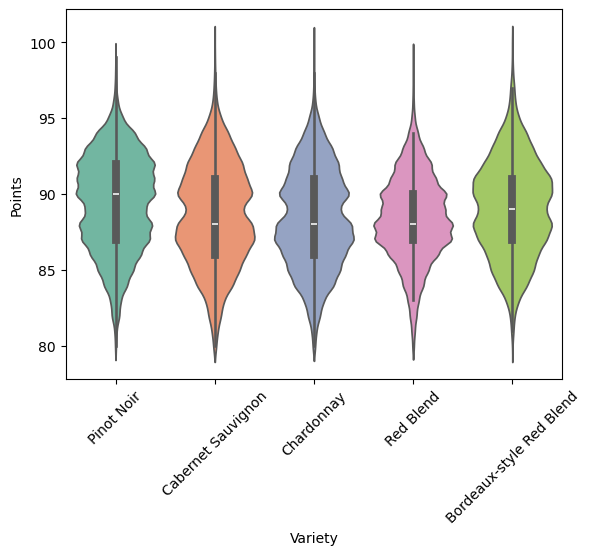

In [15]:
# Violin plot
sns.violinplot(data=df, x='variety', y='points', palette='Set2')

plt.xlabel("Variety")
plt.xticks(rotation=45)
plt.ylabel("Points")
plt.show()

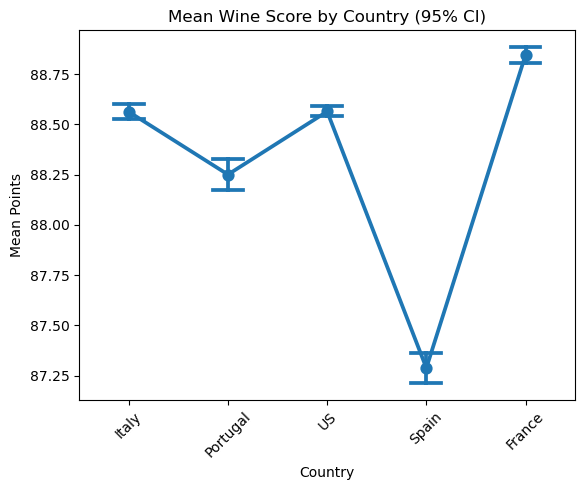

In [16]:
# Select top 5 countries by review count
top_countries = reviews['country'].value_counts().head(5).index
df = reviews[reviews['country'].isin(top_countries)]

# Point plot
sns.pointplot(data=df, x='country', y='points', estimator='mean', errorbar=('ci', 95), capsize=0.3)

plt.title("Mean Wine Score by Country (95% CI)")
plt.xlabel("Country")
plt.ylabel("Mean Points")
plt.xticks(rotation=45)
plt.show()

# Multivariate Analysis

### Pairwise Relationships

In [17]:
wine_counts = pd.read_csv("data/02-top-five-wine-score-counts.csv", index_col=0)
wine_counts.head()

,Bordeaux-style Red Blend,Cabernet Sauvignon,Chardonnay,Pinot Noir,Red Blend
points,,,,,
80,5.0,87.0,68.0,36.0,72.0
81,18.0,159.0,150.0,83.0,107.0
82,72.0,435.0,517.0,295.0,223.0
83,95.0,570.0,669.0,346.0,364.0
84,268.0,923.0,1146.0,733.0,602.0


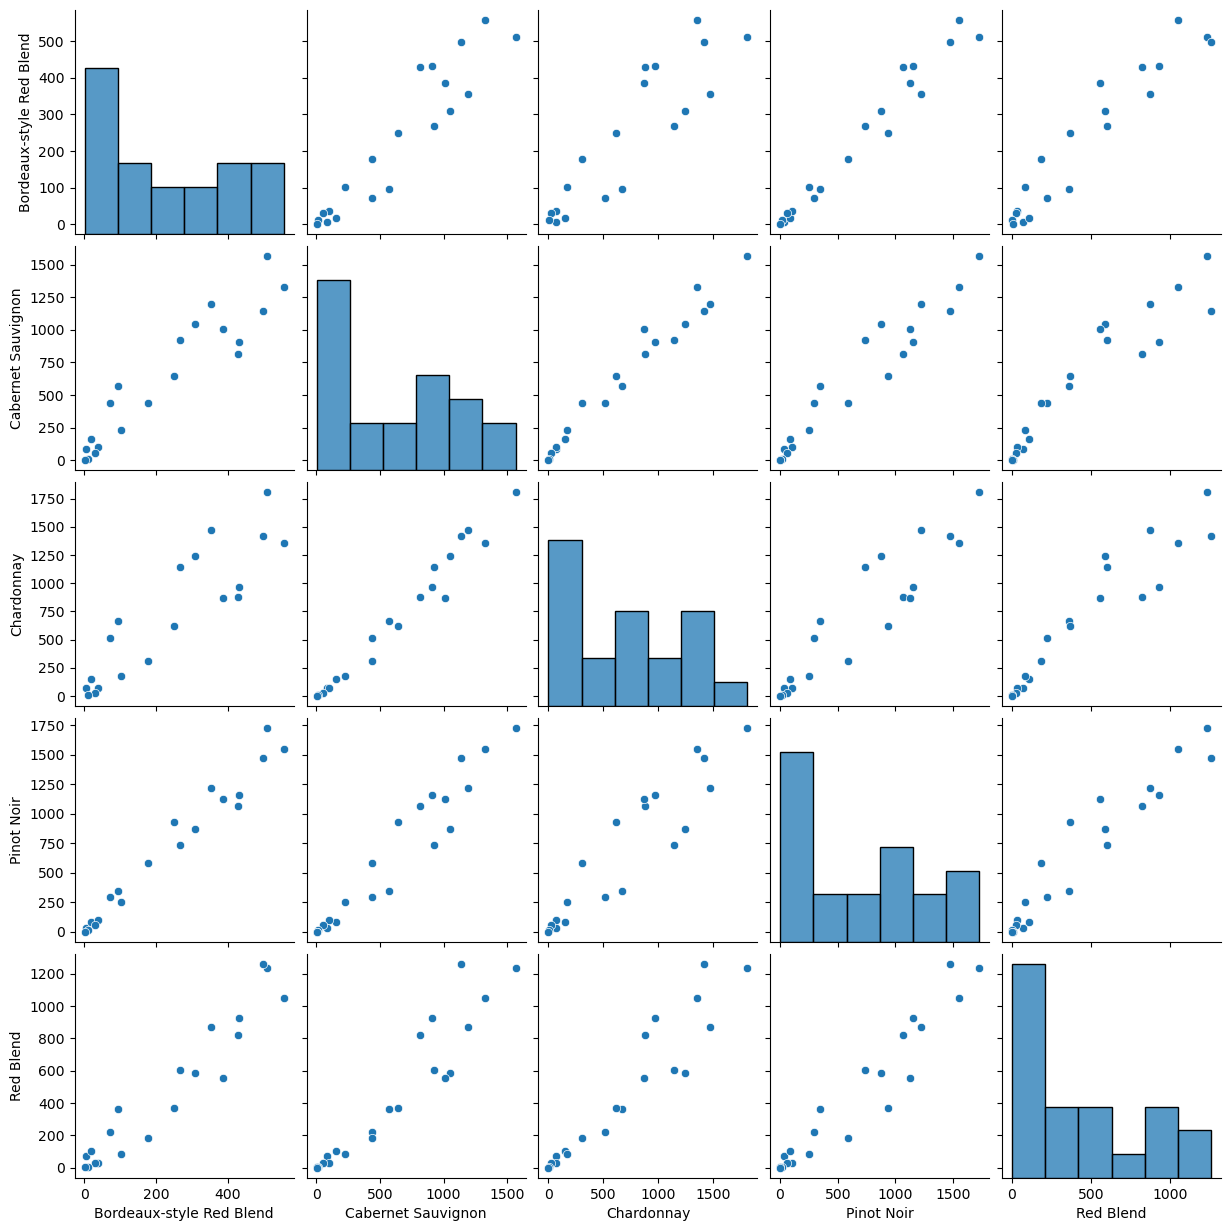

In [18]:
# Pairplot
sns.pairplot(wine_counts)

<Axes: >

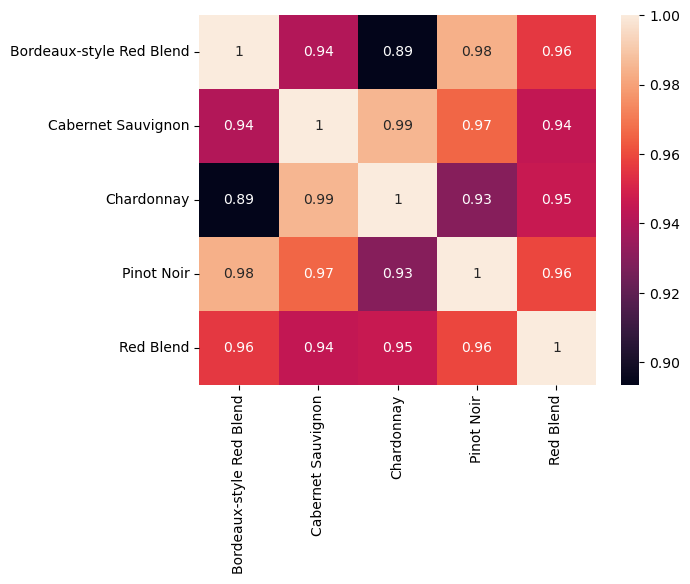

In [19]:
# Heat map for correlation visualization
corr = wine_counts.corr()
sns.heatmap(corr, annot = True)

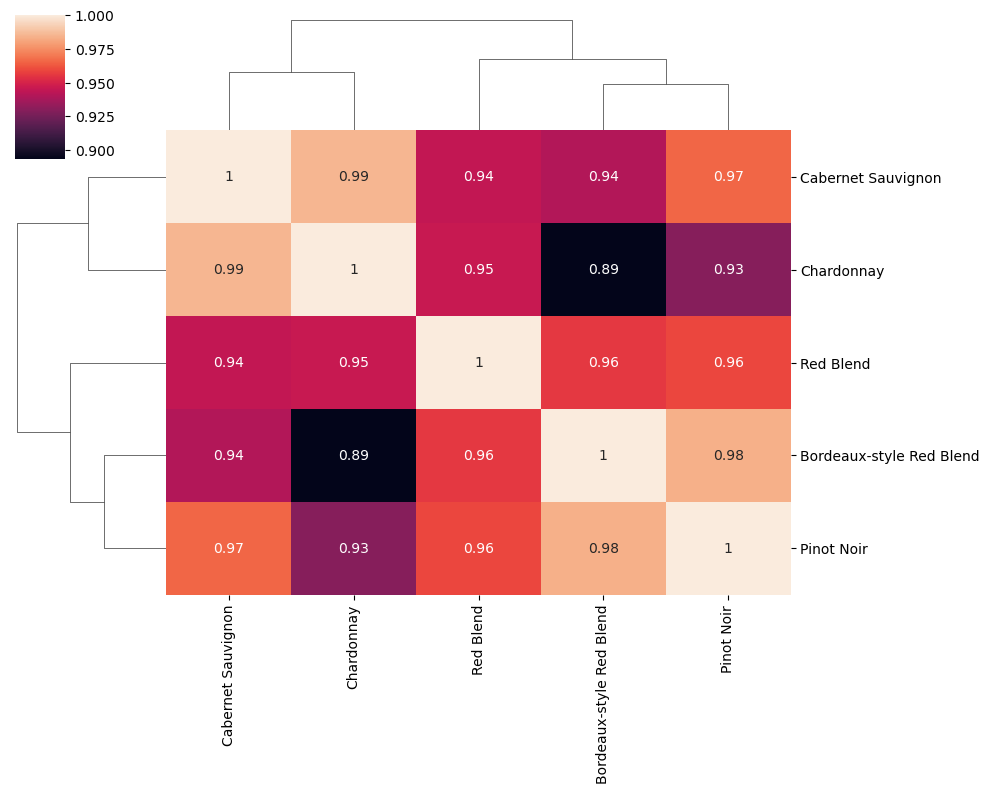

In [20]:
# Create clustered heatmap
sns.clustermap(corr, annot=True, figsize=(10, 8))

plt.show()

# Time Series Visualization

### Create a synthetic time series

In [6]:
import numpy as np

# Reproducibility
np.random.seed(42)

# Create date range
dates = pd.date_range(start="2025-01-01", periods=365)

# Components
trend = np.linspace(0, 50, 365)                     # linear trend
seasonality = 20 * np.sin(np.linspace(0, 10, 365))  # smooth seasonality
noise = np.random.normal(0, 5, 365)                 # Gaussian noise (mean=0, std=5)

# Combine components
values = trend + seasonality + noise

# Create DataFrame
ts = pd.DataFrame({"date": dates, "value": values})

### Line chart

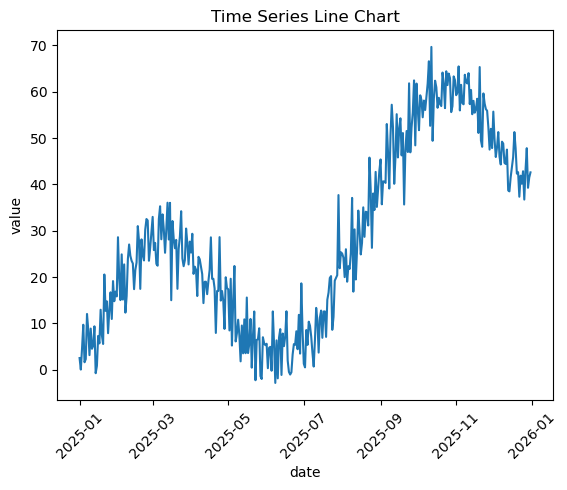

In [7]:
sns.lineplot(data=ts, x="date", y="value")

plt.title("Time Series Line Chart")
plt.xticks(rotation=45)
plt.show()

### Rolling Mean (Smoothing)

<Axes: xlabel='date', ylabel='value'>

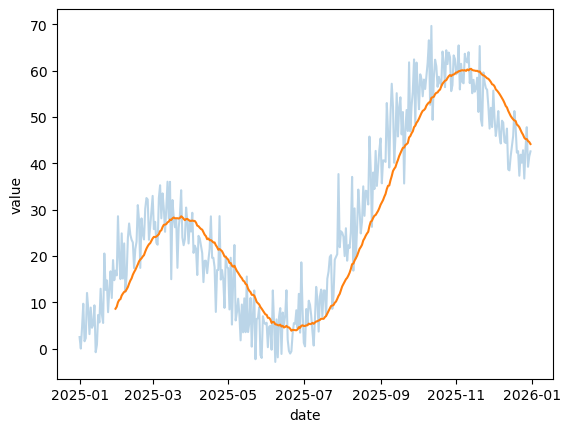

In [8]:
ts['rolling_mean'] = ts['value'].rolling(window=30).mean()

sns.lineplot(data=ts, x='date', y='value', alpha=0.3)
sns.lineplot(data=ts, x='date', y='rolling_mean')